# Part 2 — Stratify, sample, and lightly clean reviews




This notebook starts from the basic-clean checkpoint produced by `01_prepare_data.ipynb`.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

BASE_DIR = Path.cwd()
BASIC_CLEAN_FILE = BASE_DIR / "data/processed/reviews_2023_2025_basic_clean.csv"
STRATIFIED_FILE = BASE_DIR / "data/samples/reviews_sample_50000_stratified.csv"
EXTRACTION_READY_FILE = BASE_DIR / "data/samples/reviews_sample_50000_extraction_ready.csv"
TINY_TEST_FILE = BASE_DIR / "data/samples/reviews_tiny_test_24.csv"

if not BASIC_CLEAN_FILE.exists():
    raise FileNotFoundError(
        "Run 01_prepare_data.ipynb first to create "
        f"{BASIC_CLEAN_FILE.name}."
    )

df_2023_2025_basic_clean = pd.read_csv(BASIC_CLEAN_FILE)
print("Loaded rows:", len(df_2023_2025_basic_clean))


Loaded rows: 896716


## Stratify and sample 50000 comments

### Comparison of possible stratification variables（column headers）


In [2]:
df_check = df_2023_2025_basic_clean.copy()

df_check["date"] = pd.to_datetime(
    df_check["date"],
    errors="coerce"
)

df_check["year"] = df_check["date"].dt.year

listing_counts = df_check.groupby("listing_id").size()

df_check["listing_comment_count"] = (
    df_check["listing_id"].map(listing_counts)
)

df_check["listing_activity"] = pd.cut(
    df_check["listing_comment_count"],
    bins=[0, 3, 11, 42, np.inf],
    labels=["Low", "Medium", "High", "Very high"],
    include_lowest=True
)


variable_summary = pd.DataFrame({
    "Variable": [
        "id",
        "reviewer_id",
        "reviewer_name",
        "comments",
        "listing_id",
        "date",
        "year",
        "listing_activity"
    ],

    "Unique values": [
        df_check["id"].nunique(),
        df_check["reviewer_id"].nunique(),
        df_check["reviewer_name"].nunique(),
        df_check["comments"].nunique(),
        df_check["listing_id"].nunique(),
        df_check["date"].nunique(),
        df_check["year"].nunique(),
        df_check["listing_activity"].nunique()
    ],

    "Reason": [
        "Every review has a different ID",
        "Almost every reviewer is unique",
        "Too many categories and names are not analytically meaningful",
        "Unstructured text and almost every comment differs",
        "Too many direct strata",
        "Too detailed",
        "Small, meaningful, practical",
        "Small, meaningful, practical"
    ]
})

variable_summary_display = variable_summary.copy()

variable_summary_display["Unique values"] = (
    variable_summary_display["Unique values"]
    .map(lambda value: f"{value:,}")
)

print("Comparison of possible stratification variables:")
display(variable_summary_display)

Comparison of possible stratification variables:


,Variable,Unique values,Reason
0,id,"896,716",Every review has a different ID
1,reviewer_id,"733,068",Almost every reviewer is unique
2,reviewer_name,"108,841",Too many categories and names are not analytic...
3,comments,"853,821",Unstructured text and almost every comment dif...
4,listing_id,"28,227",Too many direct strata
5,date,"1,074",Too detailed
6,year,3,"Small, meaningful, practical"
7,listing_activity,4,"Small, meaningful, practical"


### Year variable support

,Comments,Percentage
year,,
2023,252174,28.12
2024,307424,34.28
2025,337118,37.59


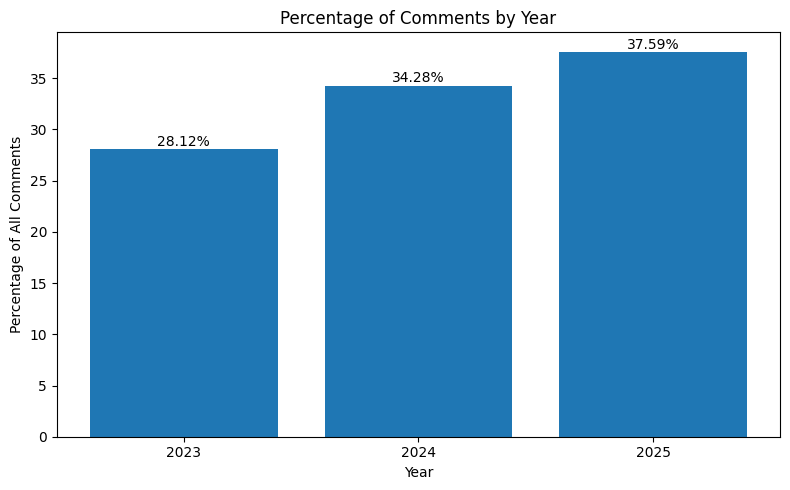

In [3]:
import matplotlib.pyplot as plt 

df_chart = df_2023_2025_basic_clean.copy()

# Create year from date
df_chart["date"] = pd.to_datetime(df_chart["date"], errors="coerce")
df_chart["year"] = df_chart["date"].dt.year

# Calculate comment count and percentage by year
year_summary = (
    df_chart["year"]
    .value_counts()
    .sort_index()
    .rename("Comments")
    .to_frame()
)

year_summary["Percentage"] = (
    year_summary["Comments"] / len(df_chart) * 100
)

display(year_summary.round(2))

# Create chart
plt.figure(figsize=(8, 5))

bars = plt.bar(
    year_summary.index.astype(str),
    year_summary["Percentage"]
)

plt.title("Percentage of Comments by Year")
plt.xlabel("Year")
plt.ylabel("Percentage of All Comments")

for bar, value in zip(bars, year_summary["Percentage"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f"{value:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [4]:
# Confirm the quartile-based listing-activity thresholds
listing_counts.describe()

count    28227.000000
mean        31.768024
std         47.871760
min          1.000000
25%          3.000000
50%         11.000000
75%         42.000000
max       1253.000000
dtype: float64

### Listing activity variable support


,Percentage of listings,Percentage of comments
listing_activity,,
Low,26.77,1.46
Medium,24.66,5.26
High,23.85,17.87
Very high,24.71,75.41


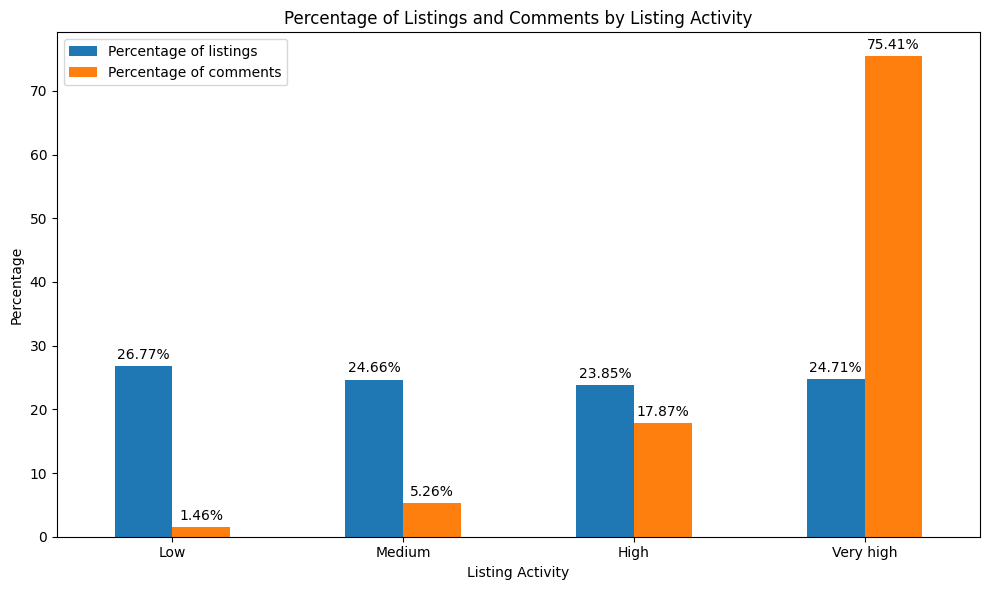

In [5]:
df_chart = df_2023_2025_basic_clean.copy()

# Count comments for each listing
listing_counts = (
    df_chart.groupby("listing_id")
    .size()
    .rename("comment_count")
    .reset_index()
)

# Create listing activity groups
activity_order = ["Low", "Medium", "High", "Very high"]

listing_counts["listing_activity"] = pd.cut(
    listing_counts["comment_count"],
    bins=[0, 3, 11, 42, np.inf],
    labels=activity_order,
    include_lowest=True
)

# Add listing activity to every comment
df_chart = df_chart.merge(
    listing_counts[["listing_id", "listing_activity"]],
    on="listing_id",
    how="left"
)

# Percentage of listings in each group
listing_percentage = (
    listing_counts["listing_activity"]
    .value_counts(normalize=True)
    .reindex(activity_order)
    * 100
)

# Percentage of comments contributed by each group
comment_percentage = (
    df_chart["listing_activity"]
    .value_counts(normalize=True)
    .reindex(activity_order)
    * 100
)

activity_summary = pd.DataFrame({
    "Percentage of listings": listing_percentage,
    "Percentage of comments": comment_percentage
})

display(activity_summary.round(2))

# Create chart
ax = activity_summary.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Percentage of Listings and Comments by Listing Activity")
plt.xlabel("Listing Activity")
plt.ylabel("Percentage")
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f%%",
        padding=3
    )

plt.tight_layout()
plt.show()

### Use listing-activity + yearly as stratification variables 


In [6]:
# Use year + listing activity to stratify and sample 50,000 comments

SAMPLE_SIZE = 50_000
RANDOM_STATE = 42

# Start with the cleaned 2023–2025 dataset
df_stratify = df_2023_2025_basic_clean.copy()

# ---------------------------------------------------------
# 1. Create year
# ---------------------------------------------------------

df_stratify["date"] = pd.to_datetime(
    df_stratify["date"],
    errors="coerce"
)

df_stratify["year"] = df_stratify["date"].dt.year

# ---------------------------------------------------------
# 2. Count comments belonging to each listing
# ---------------------------------------------------------

listing_counts = (
    df_stratify.groupby("listing_id")
    .size()
    .rename("listing_comment_count")
)

# Add the count to every comment
df_stratify["listing_comment_count"] = (
    df_stratify["listing_id"].map(listing_counts)
)

# ---------------------------------------------------------
# 3. Create listing activity groups
# ---------------------------------------------------------

activity_order = ["Low", "Medium", "High", "Very high"]

df_stratify["listing_activity"] = pd.cut(
    df_stratify["listing_comment_count"],
    bins=[0, 3, 11, 42, np.inf],
    labels=activity_order,
    include_lowest=True
)

# Check whether the stratification variables contain missing values
print("Missing year values:", df_stratify["year"].isna().sum())
print(
    "Missing listing activity values:",
    df_stratify["listing_activity"].isna().sum()
)

df_stratify.head()


Missing year values: 0
Missing listing activity values: 0


,listing_id,id,date,reviewer_id,reviewer_name,comments,year,listing_comment_count,listing_activity
0,2708,871853918823721496,2023-04-17,155646940,Mamoun,A great host in a great home!<br/>Don’t hesita...,2023,8,Medium
1,2708,947928431665277962,2023-07-31,502511212,Stephen,Charles is the man!! Just wrapped up an amazin...,2023,8,Medium
2,2708,1107399330909692945,2024-03-07,201664381,Grant,Great starting point for anyone's LA adventure...,2024,8,Medium
3,2708,1175511762719203533,2024-06-09,226451147,Hieu Trung,Very pleasant stay,2024,8,Medium
4,2708,1215421255304446322,2024-08-03,68037230,Bailey,Had a great month long stay at Charles’s apart...,2024,8,Medium


### Count comments in each year × listing-activity stratum


In [7]:
stratum_summary = (
    df_stratify
    .groupby(
        ["year", "listing_activity"],
        observed=True
    )
    .size()
    .rename("population_count")
    .reset_index()
)

stratum_summary["population_percentage"] = (
    stratum_summary["population_count"]
    / len(df_stratify)
    * 100
)

display(stratum_summary.round(2))

,year,listing_activity,population_count,population_percentage
0,2023,Low,2760,0.31
1,2023,Medium,11100,1.24
2,2023,High,33296,3.71
3,2023,Very high,205018,22.86
4,2024,Low,3005,0.34
5,2024,Medium,12486,1.39
6,2024,High,44330,4.94
7,2024,Very high,247603,27.61
8,2025,Low,7370,0.82
9,2025,Medium,23573,2.63


### Calculate proportional sample allocation

In [8]:
stratum_allocation = stratum_summary.copy()

# Exact proportional allocation before rounding
stratum_allocation["exact_sample_count"] = (
    stratum_allocation["population_count"]
    / stratum_allocation["population_count"].sum()
    * SAMPLE_SIZE
)

# First assign the whole-number portion
stratum_allocation["sample_count"] = (
    np.floor(stratum_allocation["exact_sample_count"])
    .astype(int)
)

# Save the decimal remainder
stratum_allocation["rounding_remainder"] = (
    stratum_allocation["exact_sample_count"]
    - stratum_allocation["sample_count"]
)

# Determine how many rows are still needed to reach exactly 50,000
rows_remaining = (
    SAMPLE_SIZE
    - stratum_allocation["sample_count"].sum()
)

# Give one additional row to the strata with the largest remainders
if rows_remaining > 0:
    largest_remainder_indices = (
        stratum_allocation["rounding_remainder"]
        .nlargest(rows_remaining)
        .index
    )

    stratum_allocation.loc[
        largest_remainder_indices,
        "sample_count"
    ] += 1

print(
    "Total allocated sample size:",
    stratum_allocation["sample_count"].sum()
)

display(
    stratum_allocation[
        [
            "year",
            "listing_activity",
            "population_count",
            "population_percentage",
            "sample_count"
        ]
    ].round(2)
)

Total allocated sample size: 50000


,year,listing_activity,population_count,population_percentage,sample_count
0,2023,Low,2760,0.31,154
1,2023,Medium,11100,1.24,619
2,2023,High,33296,3.71,1856
3,2023,Very high,205018,22.86,11432
4,2024,Low,3005,0.34,168
5,2024,Medium,12486,1.39,696
6,2024,High,44330,4.94,2472
7,2024,Very high,247603,27.61,13806
8,2025,Low,7370,0.82,411
9,2025,Medium,23573,2.63,1314


### Draw the sample from every stratum


In [9]:
sampled_groups = []

for _, row in stratum_allocation.iterrows():

    year_value = row["year"]
    activity_value = row["listing_activity"]
    number_to_sample = int(row["sample_count"])

    # Select one specific stratum
    stratum_data = df_stratify[
        (df_stratify["year"] == year_value) &
        (df_stratify["listing_activity"] == activity_value)
    ]

    # Sample the allocated number of comments
    stratum_sample = stratum_data.sample(
        n=number_to_sample,
        replace=False,
        random_state=RANDOM_STATE
    )

    sampled_groups.append(stratum_sample)

# Combine the sampled strata
df_sample_50000 = pd.concat(
    sampled_groups,
    ignore_index=True
)

# Randomize the final row order
df_sample_50000 = (
    df_sample_50000
    .sample(
        frac=1,
        random_state=RANDOM_STATE
    )
    .reset_index(drop=True)
)

print("Final sample size:", len(df_sample_50000))

df_sample_50000.head()

Final sample size: 50000


,listing_id,id,date,reviewer_id,reviewer_name,comments,year,listing_comment_count,listing_activity
0,1381394293982955324,1540802291260553745,2025-10-26,700835535,Zachary,"The space was very nice and in a chill, walkab...",2025,27,High
1,53113582,1040790044091837033,2023-12-06,126961018,Jennie,The home is in a quiet neighborhood. Close to ...,2023,59,Very high
2,8000915,971185613436374037,2023-09-01,288098361,Dirk,Enjoyed the stay 👍🏼,2023,4,Medium
3,11828332,950833399492116289,2023-08-04,448113737,George,It was great meeting Gary and staying at his p...,2023,61,Very high
4,876597673611642565,1520569197001080583,2025-09-28,35136865,Ariel,We absolutely loved our stay. The home is in a...,2025,48,Very high


### Check the final sample


In [10]:
print("Number of sampled rows:", len(df_sample_50000))

print(
    "Number of unique review IDs:",
    df_sample_50000["id"].nunique()
)

print(
    "Duplicated review IDs:",
    df_sample_50000["id"].duplicated().sum()
)

print(
    "Missing comments:",
    df_sample_50000["comments"].isna().sum()
)

print(
    "Earliest date:",
    df_sample_50000["date"].min()
)

print(
    "Latest date:",
    df_sample_50000["date"].max()
)

Number of sampled rows: 50000
Number of unique review IDs: 50000
Duplicated review IDs: 0
Missing comments: 0
Earliest date: 2023-01-01 00:00:00
Latest date: 2025-12-08 00:00:00


In [11]:
#For stratified sampling, we want variables that create meaningful groups, 
#not individual identities.
#the one that is meaningful for your research goal and not too complicated.

In [12]:
#Before sampling, we can delete unusable comment rows directly. 
#After sampling, we should only clean the text format and avoid deleting rows, 
#so the final sample still contains 50,000 comments.
#extra work is the main practical reason.

### Compare distributions 


In [13]:
activity_order = ["Low", "Medium", "High", "Very high"]

# 1. Year distribution
year_comparison = pd.DataFrame({
    "Original percentage": (
        df_stratify["year"]
        .value_counts(normalize=True)
        .sort_index()
        * 100
    ),
    "Sample percentage": (
        df_sample_50000["year"]
        .value_counts(normalize=True)
        .sort_index()
        * 100
    )
})

year_comparison["Difference"] = (
    year_comparison["Sample percentage"]
    - year_comparison["Original percentage"]
)

print("Year distribution comparison:")
display(year_comparison.round(3))


# 2. Listing activity distribution
activity_comparison = pd.DataFrame({
    "Original percentage": (
        df_stratify["listing_activity"]
        .value_counts(normalize=True)
        .reindex(activity_order)
        * 100
    ),
    "Sample percentage": (
        df_sample_50000["listing_activity"]
        .value_counts(normalize=True)
        .reindex(activity_order)
        * 100
    )
})

activity_comparison["Difference"] = (
    activity_comparison["Sample percentage"]
    - activity_comparison["Original percentage"]
)

print("Listing activity distribution comparison:")
display(activity_comparison.round(3))


# 3. Combined year × listing activity distribution
original_joint = (
    df_stratify
    .groupby(["year", "listing_activity"], observed=True)
    .size()
    .div(len(df_stratify))
    .mul(100)
    .rename("Original percentage")
)

sample_joint = (
    df_sample_50000
    .groupby(["year", "listing_activity"], observed=True)
    .size()
    .div(len(df_sample_50000))
    .mul(100)
    .rename("Sample percentage")
)

joint_comparison = pd.concat(
    [original_joint, sample_joint],
    axis=1
).fillna(0)

joint_comparison["Difference"] = (
    joint_comparison["Sample percentage"]
    - joint_comparison["Original percentage"]
)

print("Year × listing activity distribution comparison:")
display(joint_comparison.round(3))

Year distribution comparison:


,Original percentage,Sample percentage,Difference
year,,,
2023,28.122,28.122,0.000
2024,34.283,34.284,0.001
2025,37.595,37.594,-0.001


Listing activity distribution comparison:


,Original percentage,Sample percentage,Difference
listing_activity,,,
Low,1.465,1.466,0.001
Medium,5.259,5.258,-0.001
High,17.868,17.868,0.000
Very high,75.408,75.408,-0.000


Year × listing activity distribution comparison:


Original percentage  Sample percentage  Difference
year listing_activity                                                    
2023 Low                             0.308              0.308       0.000
     Medium                          1.238              1.238       0.000
     High                            3.713              3.712      -0.001
     Very high                      22.863             22.864       0.001
2024 Low                             0.335              0.336       0.001
     Medium                          1.392              1.392      -0.000
     High                            4.944              4.944       0.000
     Very high                      27.612             27.612      -0.000
2025 Low                             0.822              0.822       0.000
     Medium                          2.629              2.628      -0.001
     High                            9.211              9.212       0.001
     Very high                      24.933             24.932      -0.001

### Save the stratified sample 

In [14]:
output_file = r"..\python2\data/samples/reviews_sample_50000_stratified.csv"

df_sample_50000.to_csv(
    output_file,
    index=False,
    encoding="utf-8-sig"
)

print("Stratified sample saved:", output_file)

Stratified sample saved: ..\python2\data/samples/reviews_sample_50000_stratified.csv


## Light clean before extracting structured variables


In [15]:
import re
import html
import unicodedata

# Work from the final 50,000-row stratified sample
df_final = df_sample_50000.copy()

# Preserve the original comment exactly
df_final["comments_original"] = df_final["comments"]


def light_clean_comment(text):
    """
    Light cleaning only:
    - decode HTML entities
    - normalize Unicode
    - remove invisible zero-width characters
    - replace HTML <br> tags, line-break characters, and tabs with spaces
    - reduce repeated whitespace
    - keep original words, punctuation, emojis, and capitalization
    """

    if pd.isna(text):
        return ""

    text = str(text)

    # Convert entities such as &amp; into &
    text = html.unescape(text)

    # Replace HTML line-break tags with spaces
    text = re.sub(
    r"<br\s*/?>",
    " ",
    text,
    flags=re.IGNORECASE
    )

    # Normalize Unicode without removing accents or emojis
    text = unicodedata.normalize("NFC", text)

    # Remove invisible zero-width characters
    text = re.sub(r"[\u200B-\u200D\u2060\uFEFF]", "", text)

    # Replace remaining line and paragraph separators with spaces
    text = re.sub(r"[\r\n\t\u2028\u2029]+", " ", text)

    # Replace repeated whitespace with one space
    text = re.sub(r"\s+", " ", text)

    return text.strip()


# Create a separate lightly cleaned column
df_final["comments_clean"] = (
    df_final["comments_original"]
    .apply(light_clean_comment)
)


# Confirm that no HTML line-break tags remain
remaining_br_tags = (
    df_final["comments_clean"]
    .str.contains(
        r"<br\s*/?>",
        case=False,
        regex=True,
        na=False
    )
    .sum()
)

print(
    "HTML line-break tags remaining:",
    remaining_br_tags
)

assert remaining_br_tags == 0, \
    "Some HTML line-break tags remain after cleaning."

# Flag comments that unexpectedly became empty, but do not delete them
df_final["empty_after_light_clean"] = (
    df_final["comments_clean"] == ""
)

print("Total rows:", len(df_final))
print(
    "Comments empty after light cleaning:",
    df_final["empty_after_light_clean"].sum()
)

print(
    "Comments changed by light cleaning:",
    (
        df_final["comments_original"].astype("string")
        != df_final["comments_clean"].astype("string")
    ).sum()
)

display(
    df_final[
        [
            "comments_original",
            "comments_clean",
            "empty_after_light_clean"
        ]
    ].head(10)
)

HTML line-break tags remaining: 0
Total rows: 50000
Comments empty after light cleaning: 0
Comments changed by light cleaning: 11779


,comments_original,comments_clean,empty_after_light_clean
0,"The space was very nice and in a chill, walkab...","The space was very nice and in a chill, walkab...",False
1,The home is in a quiet neighborhood. Close to ...,The home is in a quiet neighborhood. Close to ...,False
2,Enjoyed the stay 👍🏼,Enjoyed the stay 👍🏼,False
3,It was great meeting Gary and staying at his p...,It was great meeting Gary and staying at his p...,False
4,We absolutely loved our stay. The home is in a...,We absolutely loved our stay. The home is in a...,False
5,Location was amazing! Very close to koreatown ...,Location was amazing! Very close to koreatown ...,False
6,"Kenny’s house is amazing, just like him. He ma...","Kenny’s house is amazing, just like him. He ma...",False
7,I could not say enough about my stay here. It ...,I could not say enough about my stay here. It ...,False
8,Simply a perfect place! located in a very quie...,Simply a perfect place! located in a very quie...,False
9,Great location and beautiful spot for the pric...,Great location and beautiful spot for the pric...,False


### Save the light cleaned file

In [16]:
output_file = r"..\python2\data/samples/reviews_sample_50000_extraction_ready.csv"

df_final.to_csv(
    output_file,
    index=False,
    encoding="utf-8-sig"
)

print("Extraction-ready file saved:", output_file)

Extraction-ready file saved: ..\python2\data/samples/reviews_sample_50000_extraction_ready.csv


## 24-comment test

### Calculate the hybrid allocation for the 24-comment test

In [17]:
TINY_SAMPLE_SIZE = 24
BASE_PER_STRATUM = 1

tiny_stratum_allocation = (
    df_final
    .groupby(
        ["year", "listing_activity"],
        observed=True
    )
    .size()
    .rename("available_count")
    .reset_index()
    .sort_values(["year", "listing_activity"])
    .reset_index(drop=True)
)

number_of_strata = len(tiny_stratum_allocation)

if number_of_strata != 12:
    raise ValueError(
        f"Expected 12 strata, but found {number_of_strata}."
    )

# Give every stratum one comment
tiny_stratum_allocation["first_allocation"] = (
    BASE_PER_STRATUM
)

remaining_comments = (
    TINY_SAMPLE_SIZE
    - tiny_stratum_allocation["first_allocation"].sum()
)

# Calculate the proportional allocation of the remaining 12
tiny_stratum_allocation["exact_extra_count"] = (
    tiny_stratum_allocation["available_count"]
    / tiny_stratum_allocation["available_count"].sum()
    * remaining_comments
)

tiny_stratum_allocation["proportional_extras"] = (
    np.floor(
        tiny_stratum_allocation["exact_extra_count"]
    )
    .astype(int)
)

tiny_stratum_allocation["rounding_remainder"] = (
    tiny_stratum_allocation["exact_extra_count"]
    - tiny_stratum_allocation["proportional_extras"]
)

# Allocate any remaining comments using largest remainders
extras_left = (
    remaining_comments
    - tiny_stratum_allocation[
        "proportional_extras"
    ].sum()
)

if extras_left > 0:
    largest_remainder_indices = (
        tiny_stratum_allocation["rounding_remainder"]
        .nlargest(extras_left)
        .index
    )

    tiny_stratum_allocation.loc[
        largest_remainder_indices,
        "proportional_extras"
    ] += 1

# Calculate the final number selected from every stratum
tiny_stratum_allocation["tiny_sample_count"] = (
    tiny_stratum_allocation["first_allocation"]
    + tiny_stratum_allocation["proportional_extras"]
)

assert (
    tiny_stratum_allocation["tiny_sample_count"].sum()
    == TINY_SAMPLE_SIZE
)

display(
    tiny_stratum_allocation[
        [
            "year",
            "listing_activity",
            "available_count",
            "first_allocation",
            "proportional_extras",
            "tiny_sample_count"
        ]
    ]
)

,year,listing_activity,available_count,first_allocation,proportional_extras,tiny_sample_count
0,2023,Low,154,1,0,1
1,2023,Medium,619,1,0,1
2,2023,High,1856,1,1,2
3,2023,Very high,11432,1,3,4
4,2024,Low,168,1,0,1
5,2024,Medium,696,1,0,1
6,2024,High,2472,1,1,2
7,2024,Very high,13806,1,3,4
8,2025,Low,411,1,0,1
9,2025,Medium,1314,1,0,1


### Draw the 24-comment sample


In [18]:
tiny_sampled_groups = []

for stratum_index, row in (
    tiny_stratum_allocation.iterrows()
):

    year_value = row["year"]
    activity_value = row["listing_activity"]
    number_to_sample = int(row["tiny_sample_count"])

    stratum_data = df_final[
        (df_final["year"] == year_value) &
        (
            df_final["listing_activity"]
            == activity_value
        )
    ]

    if len(stratum_data) < number_to_sample:
        raise ValueError(
            f"Not enough comments in "
            f"{year_value} – {activity_value}."
        )

    stratum_sample = stratum_data.sample(
        n=number_to_sample,
        replace=False,
        random_state=RANDOM_STATE + stratum_index
    )

    tiny_sampled_groups.append(stratum_sample)

# Combine all selected strata
df_tiny_24 = pd.concat(
    tiny_sampled_groups,
    ignore_index=True
)

# Randomize the final row order
df_tiny_24 = (
    df_tiny_24
    .sample(
        frac=1,
        random_state=RANDOM_STATE
    )
    .reset_index(drop=True)
)

# Add a convenient review order
df_tiny_24.insert(
    0,
    "tiny_test_order",
    range(1, len(df_tiny_24) + 1)
)

display(
    df_tiny_24[
        [
            "tiny_test_order",
            "id",
            "year",
            "listing_activity",
            "comments_clean"
        ]
    ]
)

,tiny_test_order,id,year,listing_activity,comments_clean
0,1,1220509930957696974,2024,Low,Amazing place! very safe and clean. walkable d...
1,2,1479198452275338749,2025,Low,Barbara was wonderful and the place was great!
2,3,992920833726353703,2023,Low,"Great host, super responsive and the place is ..."
3,4,1435029508957532361,2025,High,My husband and my son stayed at Michael's plac...
4,5,1146505471118629299,2024,High,Our family had a wonderful peaceful time at Jo...
5,6,1221237206429614565,2024,Medium,Great host communicated well was always there ...
6,7,1114632557538506959,2024,Very high,Great place and a few steps from the sand. Enj...
7,8,979093824582645364,2023,Medium,The area is a beautiful location on a hill the...
8,9,1422669409460426567,2025,Very high,Noah is a really amazing host which is why i m...
9,10,810219839175560438,2023,Very high,Nice and quiet place close to many shopping ar...


### Validate the 24-comment sample

In [19]:
assert len(df_tiny_24) == 24
assert df_tiny_24["id"].notna().all()
assert df_tiny_24["id"].is_unique
assert df_tiny_24["comments_clean"].notna().all()
assert df_tiny_24["comments_clean"].ne("").all()

tiny_allocation_check = (
    df_tiny_24
    .groupby(
        ["year", "listing_activity"],
        observed=True
    )
    .size()
    .rename("selected_count")
    .reset_index()
)

allocation_comparison = (
    tiny_stratum_allocation[
        [
            "year",
            "listing_activity",
            "tiny_sample_count"
        ]
    ]
    .merge(
        tiny_allocation_check,
        on=["year", "listing_activity"],
        how="left"
    )
)

assert (
    allocation_comparison["tiny_sample_count"]
    == allocation_comparison["selected_count"]
).all()

print("Tiny-test rows:", len(df_tiny_24))
print("Unique review IDs:", df_tiny_24["id"].nunique())
print(
    "Empty cleaned comments:",
    df_tiny_24["comments_clean"].eq("").sum()
)

display(allocation_comparison)

# Save the complete selected rows
tiny_output_file = (
    r"..\python2\data/samples/reviews_tiny_test_24.csv"
)

df_tiny_24.to_csv(
    tiny_output_file,
    index=False,
    encoding="utf-8-sig"
)

print("Tiny-test file saved:", tiny_output_file)

Tiny-test rows: 24
Unique review IDs: 24
Empty cleaned comments: 0


,year,listing_activity,tiny_sample_count,selected_count
0,2023,Low,1,1
1,2023,Medium,1,1
2,2023,High,2,2
3,2023,Very high,4,4
4,2024,Low,1,1
5,2024,Medium,1,1
6,2024,High,2,2
7,2024,Very high,4,4
8,2025,Low,1,1
9,2025,Medium,1,1


Tiny-test file saved: ..\python2\data/samples/reviews_tiny_test_24.csv


## Select the 120-comment development sample

Select 10 fresh comments from each year and listing-activity stratum.
Exclude all comments used in the original 24-comment structural test.

In [1]:
from pathlib import Path

import pandas as pd


# ---------------------------------------------------------
# File paths
# ---------------------------------------------------------

BASE_DIR = Path.cwd()

EXTRACTION_READY_FILE = (
    BASE_DIR / "data/samples/reviews_sample_50000_extraction_ready.csv"
)

TINY_TEST_FILE = (
    BASE_DIR / "data/samples/reviews_tiny_test_24.csv"
)

DEVELOPMENT_FILE = (
    BASE_DIR / "data/samples/reviews_development_120.csv"
)


# ---------------------------------------------------------
# Load the 50,000-comment source and the original 24 test
# ---------------------------------------------------------

if not EXTRACTION_READY_FILE.exists():
    raise FileNotFoundError(
        f"Missing file: {EXTRACTION_READY_FILE.name}"
    )

if not TINY_TEST_FILE.exists():
    raise FileNotFoundError(
        f"Missing file: {TINY_TEST_FILE.name}"
    )


df_extraction_ready = pd.read_csv(
    EXTRACTION_READY_FILE
)

df_tiny_24 = pd.read_csv(
    TINY_TEST_FILE
)


print(
    "Extraction-ready comments:",
    len(df_extraction_ready),
)

print(
    "Original test comments:",
    len(df_tiny_24),
)


# ---------------------------------------------------------
# Confirm required columns
# ---------------------------------------------------------

required_source_columns = {
    "id",
    "year",
    "listing_activity",
    "comments_clean",
}

missing_source_columns = (
    required_source_columns
    - set(df_extraction_ready.columns)
)

if missing_source_columns:
    raise KeyError(
        "Missing source columns: "
        f"{sorted(missing_source_columns)}"
    )


if "id" not in df_tiny_24.columns:
    raise KeyError(
        "The 24-comment test file does not contain id."
    )


# ---------------------------------------------------------
# Exclude every comment used in the original 24-comment test
# ---------------------------------------------------------

tiny_test_ids = set(
    df_tiny_24["id"]
    .astype(str)
)

df_development_pool = (
    df_extraction_ready[
        ~df_extraction_ready["id"]
        .astype(str)
        .isin(tiny_test_ids)
    ]
    .copy()
)


print(
    "Available after excluding the 24 comments:",
    len(df_development_pool),
)


# ---------------------------------------------------------
# Confirm that comments are usable
# ---------------------------------------------------------

df_development_pool = (
    df_development_pool[
        df_development_pool["comments_clean"]
        .fillna("")
        .astype(str)
        .str.strip()
        .ne("")
    ]
    .copy()
)


# ---------------------------------------------------------
# Confirm that all 12 expected strata are present
# ---------------------------------------------------------

expected_years = {
    2023,
    2024,
    2025,
}

expected_activity_groups = {
    "Low",
    "Medium",
    "High",
    "Very high",
}

actual_years = set(
    df_development_pool["year"]
    .astype(int)
    .unique()
)

actual_activity_groups = set(
    df_development_pool["listing_activity"]
    .astype(str)
    .unique()
)


if not expected_years.issubset(actual_years):
    raise ValueError(
        "One or more expected years are missing."
    )

if not expected_activity_groups.issubset(
    actual_activity_groups
):
    raise ValueError(
        "One or more listing-activity groups are missing."
    )


stratum_sizes = (
    df_development_pool
    .groupby(
        [
            "year",
            "listing_activity",
        ],
        observed=False,
    )
    .size()
)


if (stratum_sizes < 10).any():
    small_strata = stratum_sizes[
        stratum_sizes < 10
    ]

    raise ValueError(
        "Some strata contain fewer than 10 comments:\n"
        f"{small_strata}"
    )


# ---------------------------------------------------------
# Select 10 comments from each of the 12 strata
# ---------------------------------------------------------

df_development_120 = (
    df_development_pool
    .groupby(
        [
            "year",
            "listing_activity",
        ],
        group_keys=False,
        observed=False,
    )
    .sample(
        n=10,
        random_state=120,
    )
    .sample(
        frac=1,
        random_state=121,
    )
    .reset_index(drop=True)
)


# Add a stable order for extraction and manual review.
df_development_120.insert(
    0,
    "development_order",
    range(
        1,
        len(df_development_120) + 1,
    ),
)


# ---------------------------------------------------------
# Validate the finished sample
# ---------------------------------------------------------

development_distribution = (
    df_development_120
    .groupby(
        [
            "year",
            "listing_activity",
        ],
        observed=False,
    )
    .size()
    .rename("development_comments")
    .reset_index()
)


overlap_ids = set(
    df_development_120["id"].astype(str)
).intersection(
    tiny_test_ids
)


assert len(df_development_120) == 120, (
    "The development sample does not contain "
    "exactly 120 comments."
)

assert (
    df_development_120["id"]
    .astype(str)
    .nunique()
    == 120
), "The development sample contains duplicate IDs."

assert not overlap_ids, (
    "The development sample overlaps with "
    "the original 24-comment test."
)

assert (
    development_distribution[
        "development_comments"
    ]
    .eq(10)
    .all()
), "Each stratum must contain exactly 10 comments."


# ---------------------------------------------------------
# Save the development sample
# ---------------------------------------------------------

df_development_120.to_csv(
    DEVELOPMENT_FILE,
    index=False,
    encoding="utf-8-sig",
)


print("\nDevelopment sample created successfully.")
print("Saved comments:", len(df_development_120))
print("Unique IDs:", df_development_120["id"].nunique())
print("Overlap with original 24:", len(overlap_ids))
print("Saved file:", DEVELOPMENT_FILE.name)

display(development_distribution)

display(
    df_development_120[
        [
            "development_order",
            "id",
            "year",
            "listing_activity",
            "comments_clean",
        ]
    ].head(10)
)

Extraction-ready comments: 50000
Original test comments: 24
Available after excluding the 24 comments: 49976

Development sample created successfully.
Saved comments: 120
Unique IDs: 120
Overlap with original 24: 0
Saved file: data/samples/reviews_development_120.csv


,year,listing_activity,development_comments
0,2023,High,10
1,2023,Low,10
2,2023,Medium,10
3,2023,Very high,10
4,2024,High,10
5,2024,Low,10
6,2024,Medium,10
7,2024,Very high,10
8,2025,High,10
9,2025,Low,10


,development_order,id,year,listing_activity,comments_clean
0,1,1216130983596413464,2024,Medium,Great hosts and a beautiful spot! David and Ba...
1,2,1052318163965253380,2023,Very high,Really nicely thought out and well-kept space.
2,3,1308129742289085405,2024,Very high,"Clean, organized, easy to get in and out. I'd ..."
3,4,810273047396758029,2023,Medium,thanks for the stay really enjoyed it will boo...
4,5,992119873081175192,2023,Medium,"such a comfortable place to stay, they thought..."
5,6,907383266324818034,2023,Medium,We had a great time.
6,7,1555304315561210533,2025,Low,She was nice
7,8,1134998471789414500,2024,Medium,This place was spacious and clean. Location wa...
8,9,1095877575274830936,2024,Very high,"Great location, great place, great host - woul..."
9,10,966782241452641542,2023,Medium,This was booked for a co-worker traveling for ...
